
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 30

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M8_Dynamic_window"     

output_folder = f"results/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

global_min = dynamic_dt_smooth_log.min().min()
global_max = dynamic_dt_smooth_log.max().max()
dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

# global_min = dynamic_dt.min().min()
# global_max = dynamic_dt.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt - global_min) / (global_max - global_min))

scaler = MinMaxScaler()

# dynamic_dt_norm = pd.DataFrame(scaler.fit_transform(dynamic_dt))
static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

In [12]:
dynamic_dt_norm

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
0,0.181908,0.101764,0.068631,0.050455,0.039000,0.031149,0.025458,0.021163,0.017823,0.050679,...,0.130997,0.120476,0.110633,0.101447,0.092895,0.084953,0.077593,0.070788,0.064509,0.058727
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046022,0.038504,0.067939,0.058584,...,0.082829,0.075628,0.068973,0.062837,0.057188,0.051999,0.068292,0.062209,0.056611,0.051469
2,0.000000,0.110974,0.075256,0.110974,0.130145,0.107278,0.089832,0.076123,0.065109,0.086776,...,0.073875,0.086912,0.079407,0.072464,0.066054,0.080229,0.073224,0.066755,0.080827,0.073776
3,0.000000,0.000000,0.000000,0.066987,0.052138,0.041847,0.034326,0.100458,0.086466,0.074905,...,0.216304,0.224462,0.220504,0.205147,0.190513,0.202105,0.187618,0.187053,0.233624,0.249961
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.021957,0.019842,0.017924,0.016186,0.014611,0.013186,0.011897,0.010731,0.009678,0.008726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14637,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14638,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Convert to tensors

In [13]:
dynamic_tensor = torch.tensor(dynamic_dt_norm.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt_norm.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [14]:
dynamic_tensor.shape

torch.Size([14640, 144])

# Sliding Window approach

In [15]:
edge_index = edge_index.long()

In [16]:
# Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 3

train_dataset = CrimeWindowPyGDataset(
# train_dataset = CrimeWindowDataset(
    static_tensor, dynamic_tensor, edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
# test_dataset = CrimeWindowDataset(
    static_tensor, dynamic_tensor, edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

In [17]:
train_dataset[0]

Data(edge_index=[2, 55234], y=[14640], x_static=[14640, 11], x_dynamic=[14640, 3], num_nodes=14640)

In [18]:
# sample = train_dataset[1]
# print(sample["x_dynamic"].shape)  # [N, window_size]
# print(sample["y"].shape)          # [N]

# print(sample["x_dynamic"][0])     # node 0, window
# print(sample["y"][0])             # node 0, next month

In [19]:
edge_index

tensor([[    0,     0,     0,  ..., 14639, 14639, 14639],
        [    0,  1381,  5698,  ...,   134, 12052, 14639]])

# Static–Dynamic GNN layer

In [20]:
conv_layer = GraphConv  # SAGEConv, GraphConv, GCNConv

In [21]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.7):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin_out = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embedding=False):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Save embedding before classification
        # x_emb = x.clone()

        # Layer 2: classification logits
        x_2 = self.conv2(x, edge_index)
        x_2 = F.relu(x_2)
        out = self.lin_out(x_2)

        # return x_emb if return_embedding else x_out
        return out.squeeze(-1), x_2

# Model initialization and optimizer

In [22]:
# num_features_static = data_static.x.shape[1]
num_features_dynamic = dynamic_tensor.shape[1]
out_channels = 1

In [23]:
model = GCN(
    in_channels=W,
    hidden_channels=64,
    out_channels=out_channels
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [25]:
def train_epoch_in(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    # criterion = nn.MSELoss()

    for batch in loader:
        optimizer.zero_grad()

        preds, _ = model(
            batch.x_dynamic.to(device),
            batch.edge_index.to(device)
        )
        # print(batch.x_dynamic.shape)
        loss = criterion(preds, batch.y.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_in(model, loader, criterion, device):
    model.eval()
    # criterion = nn.MSELoss()
    total_loss = 0.0

    for batch in loader:
        preds, _ = model(
            batch.x_dynamic.to(device),
            batch.edge_index.to(device)
        )
        # breakpoint()

        loss = criterion(preds, batch.y.to(device))
        total_loss += loss.item()

    return total_loss / len(loader)


In [26]:
alpha_self_history = []
alpha_neigh_history = []
train_loss_per_epoch = []
test_loss_per_epoch = []

criterion = nn.MSELoss()

for epoch in range(num_epochs):
    train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
    # alpha_self = model.gnn.alpha_self.item()
    # alpha_neigh = model.gnn.alpha_neigh.item()

    # alpha_self_history.append(alpha_self)
    # alpha_neigh_history.append(alpha_neigh)
    train_loss_per_epoch.append(train_loss)

    test_loss = evaluate_in(model, test_loader, criterion, "cpu")
    test_loss, _, _ = evaluate_and_collect(model, test_loader, "cpu", bdynamiconly=True)

    test_loss_per_epoch.append(test_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        # f"Self → Static: {alpha_self:.3f}, Dynamic: {1-alpha_self:.3f} | "
        # f"Neigh → Static: {alpha_neigh:.3f}, Dynamic: {1-alpha_neigh:.3f} | "
        f"Test: {test_loss['MSE']:.4f}"
    )

Epoch 00 | Train: 0.0268 | Test: 0.0042
Epoch 01 | Train: 0.0076 | Test: 0.0038
Epoch 02 | Train: 0.0057 | Test: 0.0033
Epoch 03 | Train: 0.0045 | Test: 0.0028
Epoch 04 | Train: 0.0037 | Test: 0.0025
Epoch 05 | Train: 0.0033 | Test: 0.0021
Epoch 06 | Train: 0.0030 | Test: 0.0017
Epoch 07 | Train: 0.0027 | Test: 0.0014
Epoch 08 | Train: 0.0025 | Test: 0.0012
Epoch 09 | Train: 0.0023 | Test: 0.0010
Epoch 10 | Train: 0.0021 | Test: 0.0008
Epoch 11 | Train: 0.0020 | Test: 0.0007
Epoch 12 | Train: 0.0018 | Test: 0.0006
Epoch 13 | Train: 0.0017 | Test: 0.0005
Epoch 14 | Train: 0.0016 | Test: 0.0005
Epoch 15 | Train: 0.0015 | Test: 0.0005
Epoch 16 | Train: 0.0015 | Test: 0.0005
Epoch 17 | Train: 0.0014 | Test: 0.0005
Epoch 18 | Train: 0.0013 | Test: 0.0005
Epoch 19 | Train: 0.0012 | Test: 0.0005
Epoch 20 | Train: 0.0011 | Test: 0.0005
Epoch 21 | Train: 0.0011 | Test: 0.0006
Epoch 22 | Train: 0.0010 | Test: 0.0005
Epoch 23 | Train: 0.0010 | Test: 0.0006
Epoch 24 | Train: 0.0009 | Test: 0.0006


In [27]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(num_epochs)


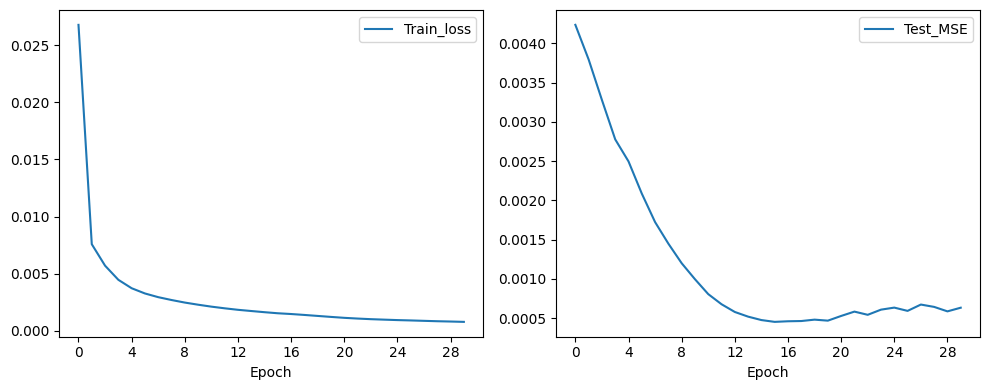

In [28]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_per_epoch, label="Train_loss")
# plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Self Contribution")
plt.xlabel("Epoch")
# plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
mse_values = [d['MSE'] for d in test_loss_per_epoch]

plt.plot(epochs, mse_values, label="Test_MSE")
# plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Train_test_Loss.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


# Predicted Time Series Analysis
## Choose High Crime Node

In [35]:
def plot_fluctuation_analysis(
    pred_matrix,
    node,
    adj,
    max_hop=2,
    mode="mean",
    output_path=None,
    filename=None,
    show_correlation=True
):
    """
    pred_matrix : shape (T, N)
    node        : central node id
    adj         : adjacency dictionary
    max_hop     : number of hops
    mode        : "mean" or "all"
    show_correlation : display correlation values in plot
    """

    T = pred_matrix.shape[0]
    time = np.arange(T)

    plt.figure(figsize=(8, 5))

    # ---- Central node ----
    central = pred_matrix[:, node]
    plt.plot(
        time,
        central,
        linewidth=3,
        color="black",
        label=f"Node {node} (Central)"
    )

    hop_colors = plt.cm.viridis(np.linspace(0.3, 0.9, max_hop))

    correlations = []

    for hop in range(1, max_hop + 1):

        neighbors = get_neighbors(node, adj, order=hop)

        if len(neighbors) == 0:
            continue

        color = hop_colors[hop - 1]

        # Mean series for hop
        hop_series = pred_matrix[:, neighbors].mean(axis=1)

        # ---- Correlation ----
        corr = np.corrcoef(central, hop_series)[0, 1]
        correlations.append((hop, corr))

        if mode == "mean":

            plt.plot(
                time,
                hop_series,
                linewidth=2,
                linestyle="--",
                color=color,
                label=f"Mean {hop}-hop (ρ={corr:.2f})"
            )

        elif mode == "all":

            for n in neighbors:
                plt.plot(
                    time,
                    pred_matrix[:, n],
                    linewidth=1.5,
                    alpha=0.4,
                    color=color
                )

            # One legend entry
            plt.plot(
                [],
                [],
                color=color,
                linewidth=2,
                label=f"{hop}-hop (ρ={corr:.2f})"
            )

    plt.xlabel("Time Step")
    plt.ylabel("Predicted Crime Intensity")
    plt.title("Spatio-Temporal Crime Evolution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Optional: correlation text box
    if show_correlation and correlations:
        corr_text = "\n".join(
            [f"{hop}-hop ρ = {corr:.3f}" for hop, corr in correlations]
        )
        plt.gcf().text(
            0.85, 0.75,
            corr_text,
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
        )

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()




In [29]:
metrics, preds_per_t, targets_per_t = evaluate_and_collect(
    model, test_loader, device = 'cpu', bdynamiconly=True
)

print(metrics)
metrics



{'MSE': 0.0006337041850201786, 'RMSE': np.float64(0.025173481781831025), 'MAE': 0.021043386310338974, 'R2': 0.7823684215545654}


{'MSE': 0.0006337041850201786,
 'RMSE': np.float64(0.025173481781831025),
 'MAE': 0.021043386310338974,
 'R2': 0.7823684215545654}

## Choose High Crime Node

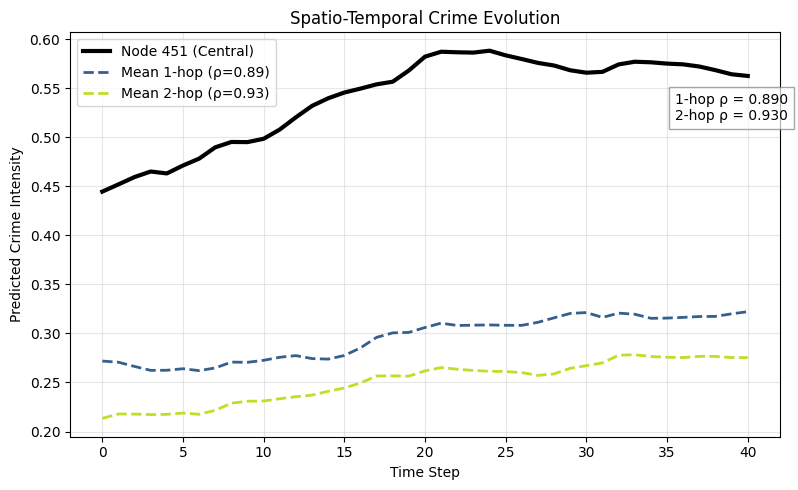

In [36]:
# Predicted Time Series Analysis
## Choose High Crime Node
adj = build_adj(edge_index)
pred_matrix = np.stack(preds_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
high_node = np.argmax(avg_pred_per_node)

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

# high_node = 451  #451
plot_fluctuation_analysis(pred_matrix, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


In [37]:
corr = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: 0.8903740332323549
Correlation with 2-hop neighbors: 0.9300651231698548


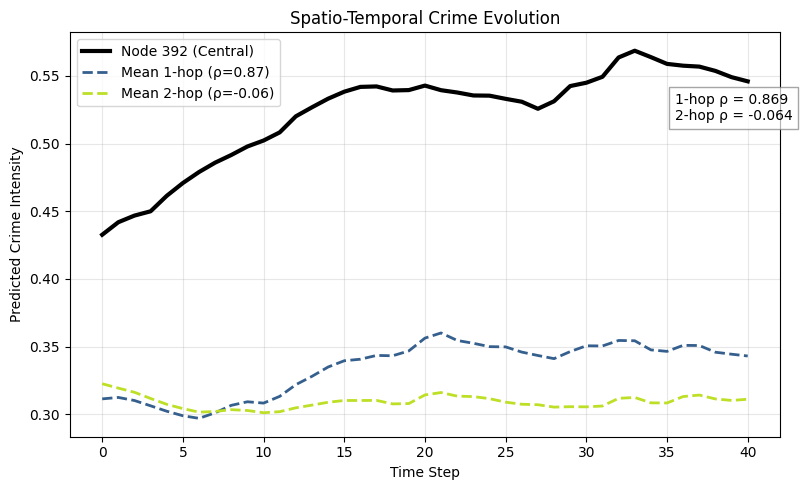

In [47]:
high_node = 392
plot_fluctuation_analysis(pred_matrix, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


In [39]:
corr = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: -0.9026307466432892
Correlation with 2-hop neighbors: -0.9468287870204934


## Find Peak valley

In [40]:
def find_peak_valley_peak_node(pred_matrix):
    T, N = pred_matrix.shape
    
    scores = []

    for n in range(N):
        series = pred_matrix[:, n]
        
        first_third = series[:T//3].max()
        middle_third = series[T//3:2*T//3].min()
        last_third = series[2*T//3:].max()
        
        score = (first_third + last_third) - middle_third
        scores.append(score)
    
    return np.argmax(scores)



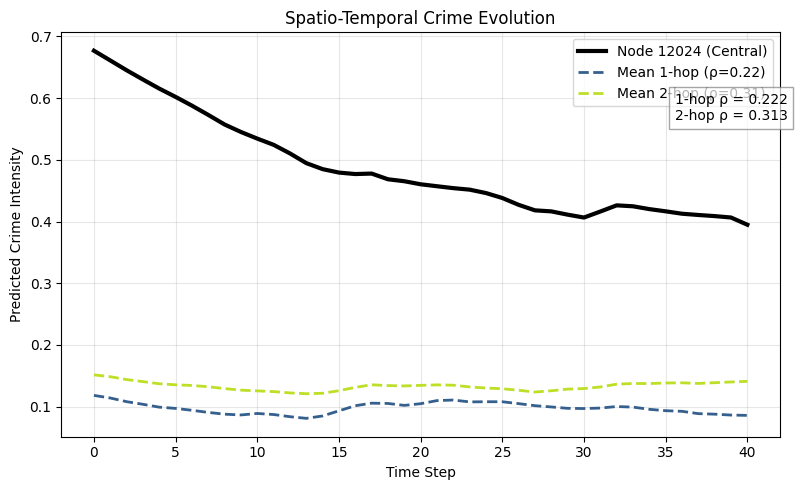

In [41]:
pred_matrix = np.stack(preds_per_t)

high_node = find_peak_valley_peak_node(pred_matrix)

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_fluctuation_curvature_node_{high_node}')



In [42]:
corr = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, high_node],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: 0.22225262671575963
Correlation with 2-hop neighbors: 0.3131561665381764


## Fluctuation by curvature

In [43]:
def fluctuation_by_curvature(pred_matrix):
    T, N = pred_matrix.shape
    curvature_scores = np.zeros(N)

    for n in range(N):
        series = pred_matrix[:, n]
        second_derivative = np.diff(series, n=0)
        curvature_scores[n] = np.sum(np.abs(second_derivative))

    return np.argmax(curvature_scores)



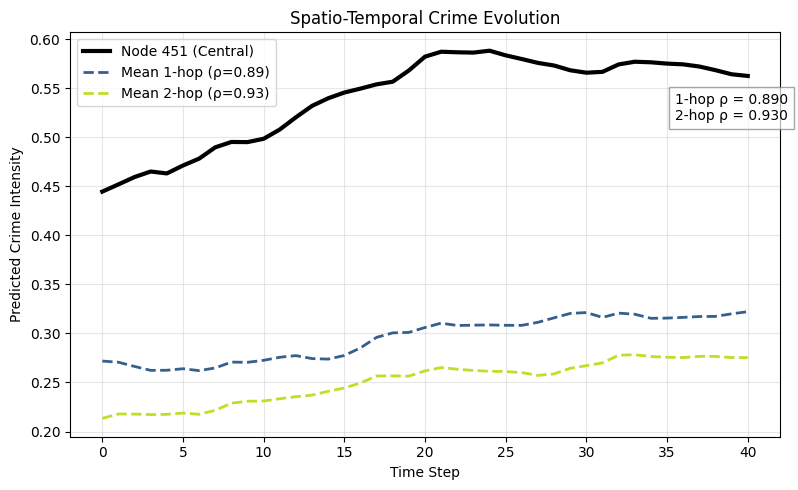

In [44]:
pred_matrix = np.stack(preds_per_t)

node_2 = fluctuation_by_curvature(pred_matrix)
# node_2 = 451 5649

neighbors_1 = get_neighbors(node_2, adj, 1)
neighbors_2 = get_neighbors(node_2, adj, 2)

# plot_fluctuation_analysis(pred_matrix, node_2, neighbors_1, neighbors_2)
plot_fluctuation_analysis(
    pred_matrix,
    node=node_2,
    adj=adj,
    max_hop=2,
    mode="mean"
)


In [45]:
corr = np.corrcoef(
    pred_matrix[:, node_2],
    pred_matrix[:, neighbors_1].mean(axis=1)
)[0,1]

corr_2 = np.corrcoef(
    pred_matrix[:, node_2],
    pred_matrix[:, neighbors_2].mean(axis=1)
)[0,1]

print("Correlation with 1-hop neighbors:", corr)
print("Correlation with 2-hop neighbors:", corr_2)


Correlation with 1-hop neighbors: 0.8903740332323549
Correlation with 2-hop neighbors: 0.9300651231698548


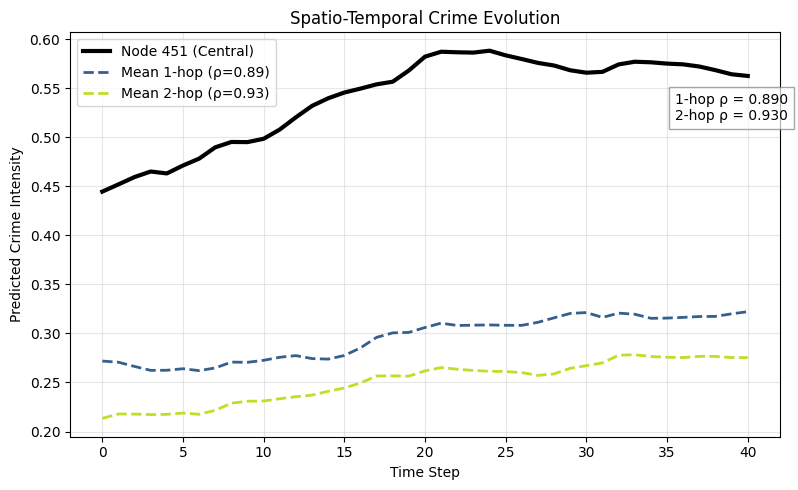

In [46]:
pred_matrix = np.stack(preds_per_t)

node_2 = fluctuation_by_curvature(pred_matrix)
# node_2 = 451 5649

neighbors_1 = get_neighbors(node_2, adj, 1)
neighbors_2 = get_neighbors(node_2, adj, 2)

# plot_fluctuation_analysis(pred_matrix, node_2, neighbors_1, neighbors_2)
plot_fluctuation_analysis(
    pred_matrix,
    node=node_2,
    adj=adj,
    max_hop=2,
    mode="mean"
)



# Embedding Projection

In [ ]:
x_dynamic_window = test_dataset.x_dynamic[:, -3:]  # last 3 months

model.eval()
_, embeddings = model(
    # test_dataset.x_static,
    x_dynamic_window,
    test_dataset.edge_index,
    return_embedding=True
)
print(f"Node Embeddings shape: {embeddings.shape}")

In [ ]:
tsne = TSNE(n_components=2, random_state=seed)
emb_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

tsne_result = pd.DataFrame(emb_2d)
tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

In [ ]:
def plot_embedding(emb_2d, filename= 'embedding', output_path = None):
    df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')
    # Save or show
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()

In [ ]:
def plot_embedding_label(emb_2d, crime_label_tensor, filename= 'embedding', output_path = None):
    df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])
    df_emb['label'] = crime_label_tensor

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_emb, x='x', y='y', hue='label', palette='Set1')
    # Save or show
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()

In [ ]:
plot_embedding(emb_2d, filename= f'embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

In [ ]:
plot_embedding_label(emb_2d, crime_label_col, filename= f'embedding_class_label{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)
